<a href="https://colab.research.google.com/github/shown5/Hands-on-Generative-AI/blob/main/chap4_diffusionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

４章 拡散モデル

本章ではテキストで内容を指示するだけで画像を生成できるモデルの仕組みを掘り下げていく。

拡散モデルの基本的な考え方は、ノイズを加えて劣化させた画像を受け取り、そのノイズを取り除いて元の鮮明な画像に復元すること。

In [1]:
%pip install genaibook

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 119.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 125.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.5 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
  Attempting uninstall: huggingface_hub
    Found 

4.1 重要な着想：反復的精緻化

拡散モデルを強力にしている要素は、GAN や VAE が最終出力を１発勝負で出力するのに対して、拡散モデルは他段階の反復を経て出力を生成する。この反復的精緻化（iterative refinement）のおかげで徐々に出力の質を高めていくことができる。


Hugging face の diffuser ライブラリを使えば事前訓練済みの拡散モデルを簡単にロードできる。ここでは初期の拡散モデルの一つである ddpm-celebahq-256 のデータセットを使って、これににた画像を生成する。

In [2]:
import torch
from diffusers import DDPMPipeline

from genaibook.core import get_device

# GPU と CPU のどっちを使うかを設定する
device = get_device()

# パイプラインを読み込む
image_pipe = DDPMPipeline.from_pretrained("google/ddpm-celebahq-256")
image_pipe.to(device)

# 画像をサンプリングする
# image_pipe().images[0]

/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your setting

model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/455M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "google/ddpm-celebahq-256",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

コードを実行すると、画像生成までに１０００ステップも要していることがわかる。
これが拡散モデルの欠点の一つ。
このサンプリングプロセスをステップごとに再現すれば、内部で何が起きているのかをより深く理解できる。

拡散プロセスの開始時、サンプルxを４枚分のランダム画像で初期化して、ここから３０ステップかけて入力画像のノイズを除去し、最終的に実データの画像に近づけていく。

In [3]:
from genaibook.core import plot_noise_and_denoise

# ランダムな初期値として４枚の画像バッチを用いる
# 各画像は３チャネル（RGB）、256*256ピクセルの画像
image = torch.randn(4, 3, 256, 256).to(device)

# 拡散ステップ数を指定する
image_pipe.scheduler.set_timesteps(num_inference_steps=30)

# 時間かかるのでコメントアウト
# サンプリングのタイムステップを繰り返す
# for i, t in enumerate(image_pipe.scheduler.timesteps):
#   with torch.inference_mode():
#     noise_pred = image_pipe.unet(image, t)["sample"]

#     scheduler_output = image_pipe.scheduler.step(noise_pred, t, image)

#     image = scheduler_output.prev_sample

#     if i % 10 == 0 or i == len(image_pipe.scheduler.timesteps) - 1:
#       plot_noise_and_denoise(scheduler_output, i)

4.2 拡散モデルの訓練

拡散モデルをゼロから訓練することで仕組みをより深く理解することを目指す。
diffusers ライブラリのコンポーネントを利用する。

以下の手順を繰り返してモデルを訓練する。
1. 訓練用データからいくつかの画像を読み込む
2. ノイズを加える ※ノイズにも多様性が必要
3. ノイズを加えた画像をモデルに与える
4. モデルがどれだけノイズを除去できたかを評価する
5. この情報を使ってモデルの重みを更新する

4.2.1 データ

今回は HuggingFace にある蝶のデータセットを使う。

In [4]:
from datasets import load_dataset

dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

次の手順で訓練に適した形に処理する。

1. 固定サイズにリサイズする
2. ランダムに反転させデータオーグメンテーションを行う
3. 画像をテンソルに変換する
4. 平均０、値が-1から1の間になるように正規化する

In [5]:
from torchvision import transforms

image_size=64

# 変換を定義する
preprocess=transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

In [6]:
def transform(examples):
  examples = [preprocess(image) for image in examples["image"]]
  return {"images": examples}


dataset.set_transform(transform)
batch_size=16

train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True
)

バッチをロードして実際の画像を確認してみる。

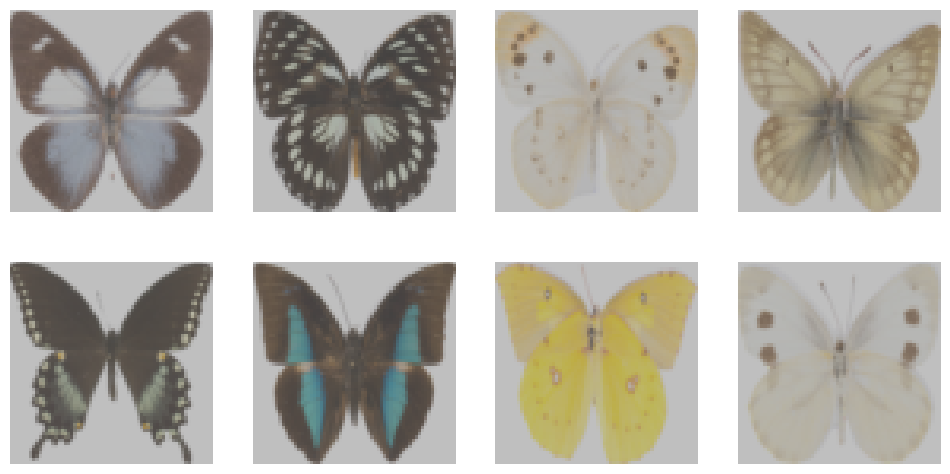

In [7]:
from genaibook.core import show_images

batch = next(iter(train_dataloader))
images = batch["images"]
show_images(images[:8]*0.5*0.5+0.5)

4.2.2 ノイズの付加

データにノイズを加えるにあたり、ノイズの量はノイズスケジュールというものによって制御される。
ノイズスケジュールの方法は様々あるが、ここでは DDPM の論文に基づく一般的な手法を実際に試してみる。

diffuser ライブラリでは Scheduler というクラスによってノイズの付加が管理される。

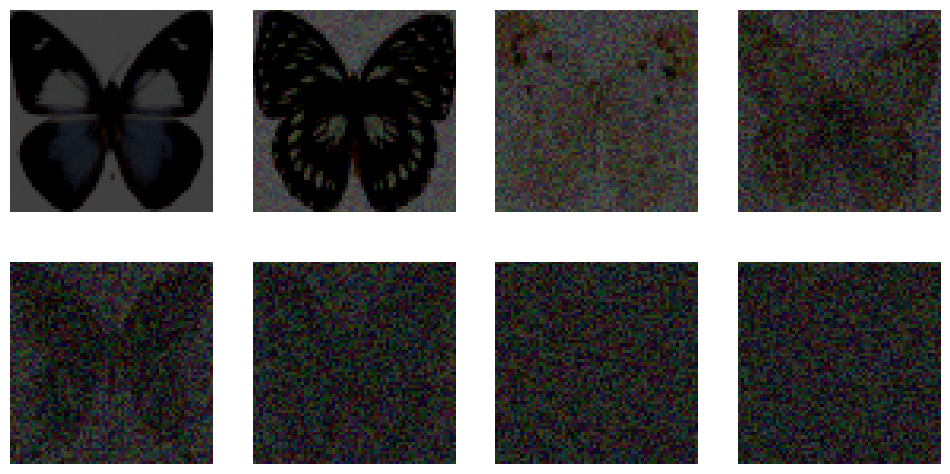

In [8]:
from diffusers import DDPMScheduler

# beta_start と beta_end については次節で説明する
scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_start=0.001, beta_end=0.02
)

# 0から999までを等間隔で８分割した値からあるテンソルを作成する
timesteps = torch.linspace(0, 999, 8).long()

# データセットから８枚の画像を読みOK身それぞれにノイズを徐々に加えていく
x = batch["images"][:8]
noise = torch.rand_like(x)
noised_x = scheduler.add_noise(x, noise, timesteps)
show_images((noised_x * 0.5 * 0.5).clip(0, 1))

4.2.3 UNet

UNet は入力と同じ形状の出力が求められる画像セグメンテーションなどのタスク向けに考案されたCNN である。UNet は入力画像の空間サイズを縮小するダウンサンプリング層とその後に空間サイズを再び拡張するアップサンプリング層から構成されている。

In [9]:
from diffusers import UNet2DModel

model = UNet2DModel(
    in_channels=3, #RGB画像なのでチャネル数は３
    sample_size=64, #入力サイズを指定
    # 各ブロックのチャネル数はモデルの規模に影響する
    block_out_channels=(64, 128, 256, 512),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
).to(device)

#バッチデータを渡して動作を確認する
with torch.inference_mode():
  out = model(noised_x.to(device), timestep=timesteps.to(device)).sample

print(noised_x.shape)
print(out.shape)

#出力結果で入力と出力のサイズが同じになっていることが確認できる
# torch.Size([8, 3, 64, 64])
# torch.Size([8, 3, 64, 64])

torch.Size([8, 3, 64, 64])
torch.Size([8, 3, 64, 64])


4.2.4 訓練

データとモデルの準備ができたので訓練していく。手順は以下の通り。

1. 画像のバッチをロード
2. 画像にノイズを加える。
3. ノイズ付与済みの画像をモデルに与える
4. MSE(平均二乗誤差)を用いて損失を計算する。MSE はUNetによるノイズ予測にも使われる。
5. 損失を逆伝播させオプティマイザーを使ってモデルの重みを更新する

In [ ]:
from torch.nn import functional as F

num_epochs = 50
lr = 1e-4 #学習率
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
losses = [] #後で表示するために損失を保存しておくリスト

#モデルを訓練する（時間かかる）
for epoch in range(num_epochs):
  for batch in train_dataloader:
    #入力画像を読み込む
    clean_images = batch["images"].to(device)

    #画像に加えるノイズをサンプリングする
    noise = torch.randn(clean_images.shape).to(device)

    #各画像ごとにランダムなタイムステップをサンプリングする
    timesteps = torch.randint(
        0,
        scheduler.config.num_train_timesteps,
        (clean_images.shape[0],),
        device=device
    ).long()

    #タイムステップごとのノイズ量に従って画像にノイズを加える
    noisy_images = scheduler.add_noise(clean_images, noise, timesteps)

    #ノイズに対するモデルの予測値を得る
    #モデルには追加の条件付けとしてタイムステプも引数に渡す
    noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

    #予測値と実際のノイズを比較する
    loss = F.mse_loss(noise_pred, noise)

    #後で表示できるように損失を保存する
    losses.append(loss.item())

    #この損失に基づきモデルのパラメーターを更新する
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

モデルの訓練が完了したので訓練損失をプロットしてみる

In [ ]:
from matplotlib import pyplot as plt

plt.subplots(1, 2, figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Training loss")
plt.xlabel("Training step")

plt.subplot(1, 2, 2)
plt.plot(range(400, len(losses)), losses[400:])
plt.title("Training loss from step 400")
plt.xlabel("Training step")

4.2.5 サンプリング

準備ができたので推論を行い画像を生成してみよう。

In [ ]:
pipeline = DDPMPipeline(unet=model, scheduler=scheduler)
ims = pipeline(batch_size=4).images
show_images(ims, nrows=1)

パイプラインに任せると内部で何やってるか分からないので、モデルが入力画像を段階的に精緻化する様子を示す簡単なサンプリングループを実装してみる。

In [ ]:
# ランダムな初期値（４枚のランダムな画像）
sample = torch.randn(4,3,64,64).to(device)

for t in scheduler.timesteps:
  #モデルによる予測値を得る
  with torch.inference_mode():
    noise_pred = model(sample, t)["sample"]

  #ステップごとにサンプルを更新する
  sample = scheduler.step(noise_pred, t, sample).prev_sample

show_images(sample.clip(-1, 1) * 0.5 + 0.5, nrows=1)

4.2.6 評価

生成モデルの評価は複雑であるとともに、本質的に主観的な作業になる。
一般的な評価方法は、人間による比較などの定性的評価と、評価の枠組みを与える定量的指標を組み合わせること。

FID（Frechet Inception Distance）スコアは生成モデルの性能評価に利用できる指標の一つ。FID スコアは２つの画像データセット間の類似度を比較する。

4.3 詳解：ノイズスケジュール

どれだけのノイズを加えるのかは非常に重要な設計上の判断になる。
その理由を以下で掘り下げていく。

4.3.1 ノイズを加える理由

拡散モデルの鍵となる考え方は「反復的精緻化」にある。
訓練時に破損させ、それを復元させるプロセスをもっと最終的に良い結果に辿り着くことを目指す。

これまで焦点を当ててきたのはガウスノイズを加えるという方法。
拡散モデルの理論的な基盤がガウスノイズの使用を前提としているからこの方法をとってきた。
他の方法でも可能。
例えばノイズを加えなくても良い。画像変換を採用しても良い。これを採用しているモデルもある。

とはいえ一般的な手法といえばガウスノイズが採用されている。その理由は以下の２つ。
- ノイズの量を容易に制御できるため、「完全な状態」から「完全に破損した状態」までをなめらかに遷移させることができる。
- 推論時の開始点をランダムに設定できる。他の手法だと、完全に破損した状態から開始する必要がある。



4.3.2 シンプルな実装から

ノイズ付加の破損手法をまずは見ていく。

In [ ]:
x = next(iter(train_dataloader))["images"][:8]
noise = torch.rand_like(x)

In [ ]:
def corrupt(x, noise, amount):
  #amount が元のデータに適合するように形状を変更する
  amount = amount.view(-1, 1, 1, 1)

  #指定したamountに基づき元データとノイズを混合する
  return (
      x * (1 - amount) + noise * amount
  )

In [ ]:
amount = torch.linspace(0, 1, 8)
noised_x = corrupt(x, noise, amount)
show_images(noised_x * 0.5 + 0.5)

In [ ]:
class SimpleScheduler:
  def __init__(self):
    self.num_train_timesteps = 1000

  def add_moise(self, x, noise, timesteps:
    amount = timesteps / self.num_train_timesteps
    return  corrupt(x, noise, amount)


scheduler = SimpleScheduler()
timesteps = torch.linspace(0, 999, 8).long()
noised_x = scheduler.add_noise(x, noise, timesteps)
show_images(noised_x * 0.5 + 0.5)

これで diffusers ライブラリで使われているスケジューラーなどと比較できるものができた。比較してみよう。

In [ ]:
scheduler = DDPMScheduler(beta_end=0.01)
timesteps = torch.linspace(0, 999, 8).long()
noised_x = scheduler.add_noise(x, noise, timesteps)
show_images((noised_x * 0.5 + 0.5).clip(0, 1))

4.3.3 数学的な背景

一旦スキップ。

4.3.4 入力解像度とスケーリングの影響

ノイズスケジュールのサイズと加工先の画像のサイズのスケールを揃えないと意図したノイズにならない。
これを解決する SimpleDiffusion は入力画像のサイズに応じてノイズスケジュールを調整する。

In [ ]:
import numpy as np
from genaibook.core import load_image, SampleURL

scheduler = DDPMScheduler(beta_end=0.05, beta_schedule="scaled_linear")
image = load_image(
    SampleURL.DogExample,
    size=((512, 512)),
    return_tensor=True
)

t = torch.tensor(300)#ノイズを加えるタイムステップ
scales = np.linspace(0.1, 1.0, 4)

images = [image]
noise = torch.randn_like(image)
for b in reversed(scales):
  noised = (
      scheduler.add_noise(b * (image * 2 - 1), noise, t).clip(-1, 1) * 0.5 + 0.5
  )
  images.append(noised)

show_images(
    images:[1:],
    nrows=1,
    titles=[f"Scale: {b}" for b in reversed(scales)],
    figsize=(15, 5),
)